In [1]:
import os
import zipfile
import pyarrow.parquet as pq
import pandas as pd

folder = r"F:\sanazi\python\data science\code\tamrin\proje\Tennis Schema\Tennis Schema\tennis_data"

data = {}

for file in os.listdir(folder): 
    if file.endswith(".zip"): 
        zip_path = os.path.join(folder, file) 

        with zipfile.ZipFile(zip_path) as z: 
            for parquet_file in z.namelist():
                if parquet_file.endswith(".parquet"): 

                    with z.open(parquet_file) as f: 
                        df = pq.read_table(f).to_pandas()
                    table_name =os.path.basename(os.path.dirname(parquet_file))[4:-8] + os.path.basename(parquet_file)[:-17] 

                    if table_name not in data:
                        data[table_name] = [] 
                    data[table_name].append(df) 


for table_name in data:
    data[table_name] = pd.concat(data[table_name], ignore_index=True)

print(data.keys())

C:\Users\sepehr\AppData\Local\Temp\ipykernel_15724\661795369.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data[table_name] = pd.concat(data[table_name], ignore_index=True)


dict_keys(['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes'])


In [2]:
tournament = data["matchtournament"]


ground = tournament.dropna(subset=["ground_type"])


surface_count = ground["ground_type"].value_counts()

print(surface_count)

ground_type
Hardcourt outdoor    16959
Red clay             11856
Hardcourt indoor      4741
Red clay indoor        512
Grass                  509
Carpet indoor          276
Synthetic outdoor      226
Green clay              30
Name: count, dtype: int64


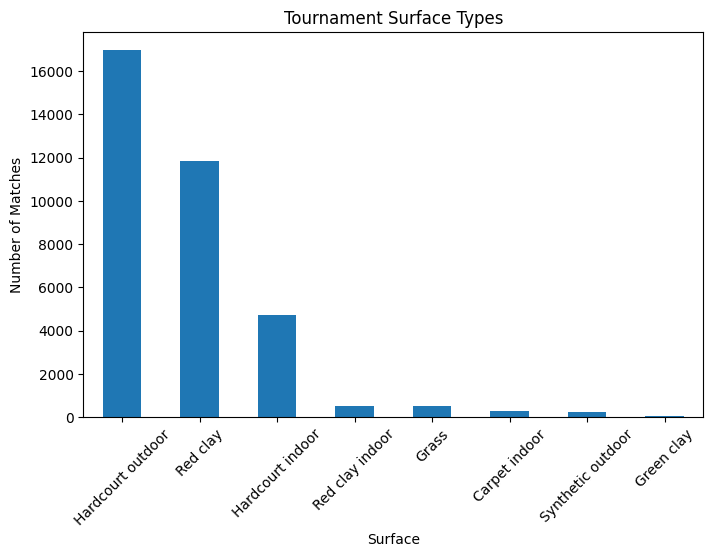

In [3]:
import matplotlib.pyplot as plt

surface_count.plot(kind="bar", figsize=(8,5))

plt.title("Tournament Surface Types")
plt.xlabel("Surface")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

plt.show()